# Introducción Aprendizaje Estadístico
Este notebook resume tres ideas centrales del aprendizaje estadistico: 
1. El problema de sesgo (aproximacion) vs varianza (estimacion)
2. El metodo de validacion cruzada para: estimar el valor esperado del error fuera de muestra y elegir hiperparametros.
3. El metodo de regularizacion para controlar la complejidad de un modelo.   

## Table of Contents

- [Scikit-Learn](#1)
- [Datos y exploracion inicial](#2)
- [Separar muestra de entrenamiento y prueba](#3)
- [Arboles de Clasificacion](#4)
- [Validacion cruzada](#5)



<a name='1'></a>
## Scikit-Learn ##

Es una librería creada a partir de *numpy, matplotlib y scipy* que provee una gran cantidad de algoritmos de ML para ejecutar tareas de clasificación, regresión, reducción de dimensionalidad y segmentación. También contiene funcionalidades para extraer características, procesamiento y selección de variables y evaluación de modelos.

- Instalación: i) pip install -U scikit-learn

Sklearn cuenta con múltiples módulos y cada módulo cuenta con varias funciones. Principales módulos:

- sklearn.datasets
- sklearn.preprocessing
- sklearn.impute
- sklearn.cross_validation
- sklearn.linear_model
- sklearn.neighbors
- sklearn.ensemble
- sklearn.cluster
- sklearn.metrics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
from collections import Counter
from matplotlib.colors import ListedColormap
from sklearn.model_selection import cross_val_score


<a name='2'></a>
## Datos y Exploracion Inicial ##

In [2]:
from sklearn.datasets import make_moons   # Importar el módulo make moons desde scikit learn para crear los datos

# Usar make_moons para crear una base de datos de 1000 observaciones con 0.2 desviaciones estándar de ruido gausiano, establezca como semilla 888

X, y = make_moons(n_samples= 1000, random_state=888, noise=0.2)

print(X[:10, ])
print(y[:10])


# Mostrar las proporciones de la marca (variable a predecir)
import numpy as np
np.sum(y)/len(y)

[[ 0.57925087 -0.43900292]
 [ 1.7410703   0.41655357]
 [ 2.16670204  0.28401191]
 [ 0.03747799  1.31372085]
 [ 0.08191925  1.21323957]
 [-1.22405263  0.92110719]
 [ 0.94018675 -0.13779717]
 [ 0.6545524   0.64399088]
 [-0.75625927  0.28222399]
 [-0.52831931  0.50104647]]
[1 1 1 0 0 0 1 0 0 1]


0.5

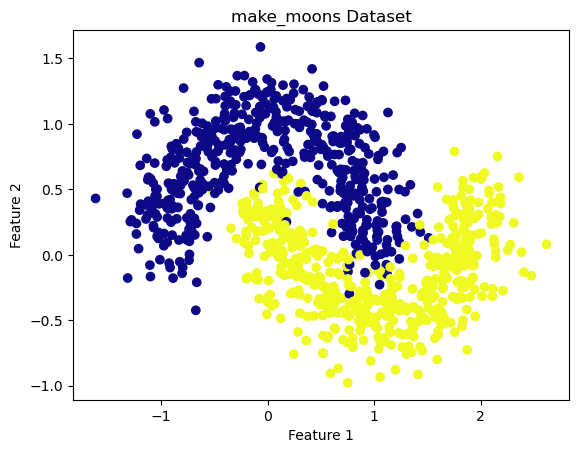

In [3]:
# Plotting the dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='plasma')
plt.title("make_moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

<a name='3'></a>
## Separar muestra de entrenamiento y prueba ##


In [4]:
# Importar la función train_test_split desde el módulo model_selection (sklearn)

from sklearn.model_selection import train_test_split

# Separar datos de entrenamiento y prueba: 70% entrenamiento, 30% prueba (usar train_test_split)

x_train, x_test, y_train, y_test = train_test_split(X, y, random_state=888, test_size=0.3)

In [5]:
print(x_train.shape)
type(x_train)
print(y_train.shape)
type(y_train)

(700, 2)
(700,)


numpy.ndarray

### Crear modelos de arboles con diferentes complejidades: numero de ejemplo en la hojas

In [6]:
# Entrenar un modelo basico de arboles
# Entrenamiento y desempeño arbol en base de prueba 
clf = tree.DecisionTreeClassifier(min_samples_split=2)
clf = clf.fit(x_train, y_train)
# Predictions
y_pred = clf.predict(x_test)

# Evaluate Model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# ROC-AUC (for binary classification only)
if len(set(y)) == 2:  # Check for binary classification
    y_prob = clf.predict_proba(x_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)
    print(f"ROC-AUC: {roc_auc:.2f}")

Accuracy: 0.96
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       157
           1       0.95      0.97      0.96       143

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300

ROC-AUC: 0.96


### Fronteras de Decision

In [7]:
def graficar_fronteras(X,y, model,  h=0.02, b=0.05):
    
    '''Esta función sirve para graficar la frontera generada por la configuración de K-vecinos más cercanos.
       Argumentos de entrada: X (características), y (marca), modelo de knn.
    '''  

    # Graficar una frontera de decisión, para ello, asignamos un color a cada punto en la malla  [x_min, x_max]x[y_min, y_max]
    x_min, x_max = X[:, 0].min() - b, X[:, 0].max() + b
    y_min, y_max = X[:, 1].min() - b, X[:, 1].max() + b
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    boundary = model.predict(np.c_[xx.ravel(), yy.ravel()])
    
    # Colocar el resultado en gráfico de color
    boundary = boundary.reshape(xx.shape)  
    cmap_light = ListedColormap(['orange', 'cyan', 'cornflowerblue'])
    cmap_bold = ListedColormap(['darkorange', 'c', 'darkblue'])
    plt.figure()
    plt.pcolormesh(xx, yy, boundary, cmap=cmap_light)

    # Graficar también los datos reales
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold,edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.axis('tight')

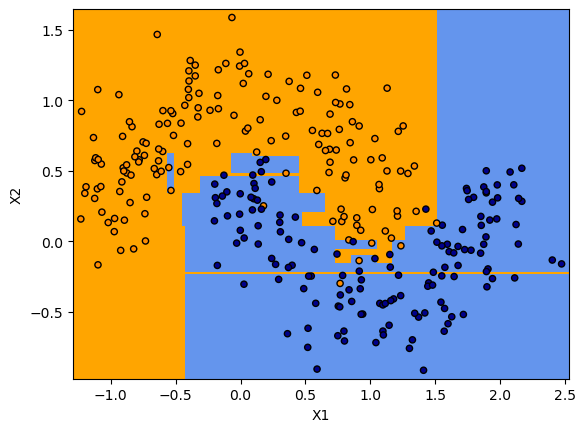

In [8]:
# Usar la función graficar_fronteras para visualizar la frontera generada por 400 y 1 vecinos más cercanos en los datos de prueba

graficar_fronteras(x_test, y_test, clf)

### Función de pérdida

Pregunta fundamental: **¿óptimo en qué sentido?** -> Métricas de desempeño

Existen muchas medidas que nos permiten saber el grado de equivocación de nuestro modelo. La más básica para problemas de clasificación es *accuracy* (usar con cuidado!). Teniendo en cuenta la matriz de confusión,

![title](MC.png)


**accuracy o exactitud** se calcula como $\frac{VP+VN}{VP+VN+FP+FN}$

### Sesgo vs Varianza

In [9]:
# Importar accuracy_score desde el módulo metrics (sklearn)

from sklearn.metrics import accuracy_score

# Crear un loop (for) para validar el resultado en accuracy para distintos k. Guardar los resultados en entrenamiento y prueba
train_scores = []
test_scores = []
split_size = range(2,600)

for k in split_size:
    clf = tree.DecisionTreeClassifier(min_samples_split=k)
    clf = clf.fit(x_train, y_train)

    train_scores.append(1-accuracy_score(y_train, clf.predict(x_train)))
    test_scores.append(1- accuracy_score(y_test, clf.predict(x_test)))

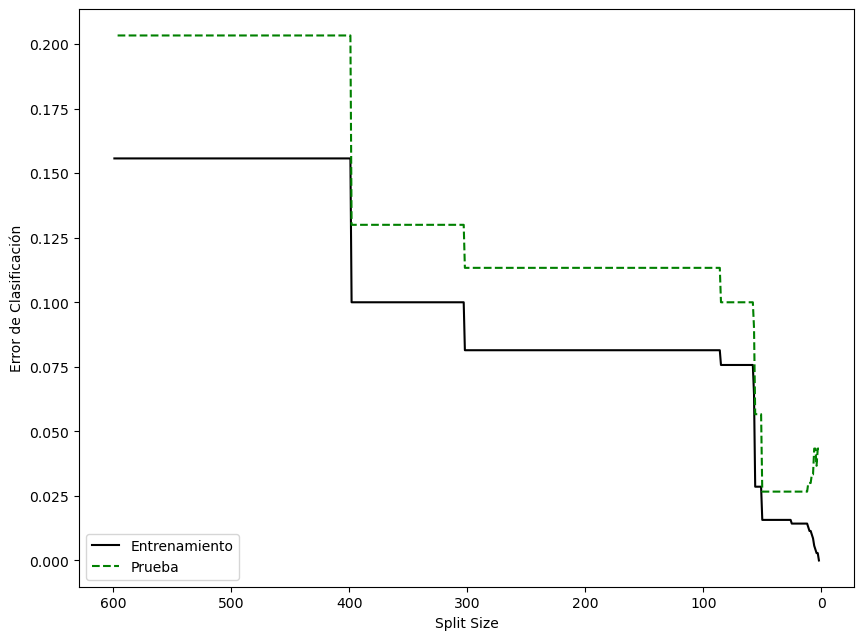

In [10]:
# Gráfique los resultados del loop

plt.figure(figsize=(10,7.5))
plt.plot(split_size, train_scores, c="black", label="Entrenamiento")
plt.plot(split_size, test_scores, c="green", linestyle="--", label="Prueba")
plt.xlabel('Split Size')
plt.ylabel('Error de Clasificación')
plt.gca().invert_xaxis()
plt.legend(loc = "lower left")
plt.show()

In [12]:
min_value = min(test_scores)
min_index = test_scores.index(min_value)
print("número óptimo de vecinos en prueba", split_size[min_index])

número óptimo de vecinos en prueba 12


### Validacion Cruzada

In [16]:
cv_mean_scores = []
for k in split_size:
    clf = tree.DecisionTreeClassifier(min_samples_split=k)
    scores = 1-cross_val_score(clf, X, y, cv=10)
    mean_scores=np.mean(scores)
    cv_mean_scores.append(mean_scores)

In [17]:
length = len(cv_mean_scores)
print("Número de elementos en cv_mean_scores:", length)

Número de elementos en cv_mean_scores: 598


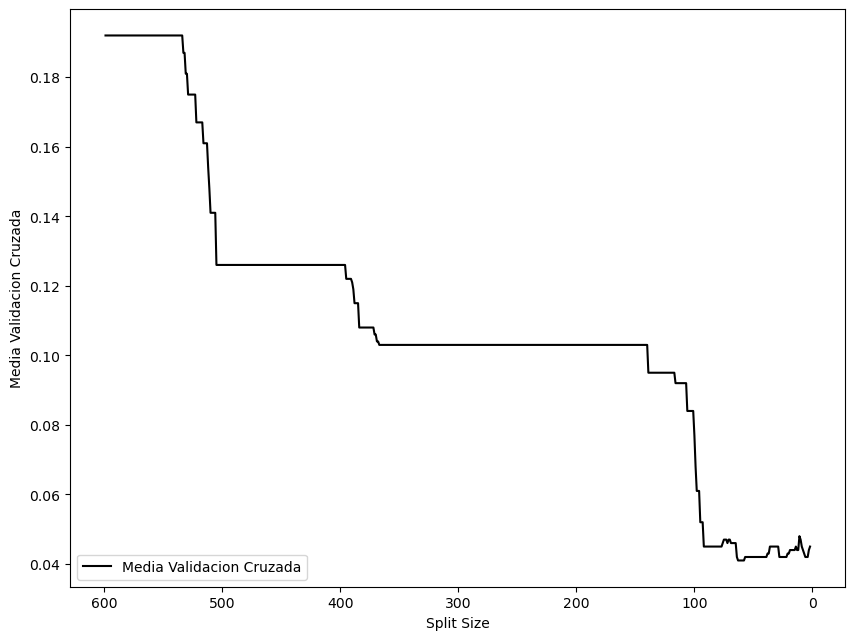

In [18]:
plt.figure(figsize=(10,7.5))
plt.plot(split_size, cv_mean_scores, c="black", label="Media Validacion Cruzada")
plt.xlabel('Split Size')
plt.ylabel('Media Validacion Cruzada')
plt.gca().invert_xaxis()
plt.legend(loc = "lower left")
plt.show()